In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [43]:
# 1. Load Data
df = pd.read_csv('../data/processed/advanced_gold_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna() # Remove any NaN values from lag/rolling creations

In [44]:
# 2. Select Features and Target
target_col = 'Target_Next_LogRet'
# Drop Date and the other target to prevent data leakage
features = df.drop(columns=['Date', 'Target_Next_Price', target_col]).columns.tolist()

In [45]:
# 3. Scaling
# We scale features and target separately to easily inverse_transform later
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[[target_col]])

In [46]:
# 4. Sequence Windowing Function
def create_sequences(features_data, target_data, lookback=14):
    X, y = [], []
    for i in range(len(features_data) - lookback):
        X.append(features_data[i:(i + lookback)])
        y.append(target_data[i + lookback])
    return np.array(X), np.array(y)

lookback_window = 14
X, y = create_sequences(scaled_features, scaled_target, lookback=lookback_window)

In [47]:
# 5. Train / Val / Test Split (Time-based, NO Shuffle)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (965, 14, 27) | y_train shape: (965, 1)
X_val shape: (207, 14, 27)


Epoch 1/100


/home/arshiaask/projects/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0422 - mae: 0.1546 - val_loss: 0.0090 - val_mae: 0.0730
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - mae: 0.0901 - val_loss: 0.0065 - val_mae: 0.0581
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0120 - mae: 0.0849 - val_loss: 0.0071 - val_mae: 0.0614
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0112 - mae: 0.0825 - val_loss: 0.0073 - val_mae: 0.0626
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - mae: 0.0787 - val_loss: 0.0069 - val_mae: 0.0603
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098 - mae: 0.0776 - val_loss: 0.0088 - val_mae: 0.0709
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098 - mae: 0.0775 - val_loss: 0.0075 - val_mae: 0.0637
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - mae: 0.0744 - val_loss: 0.0067 - val_mae: 0.0592
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - mae: 0.0

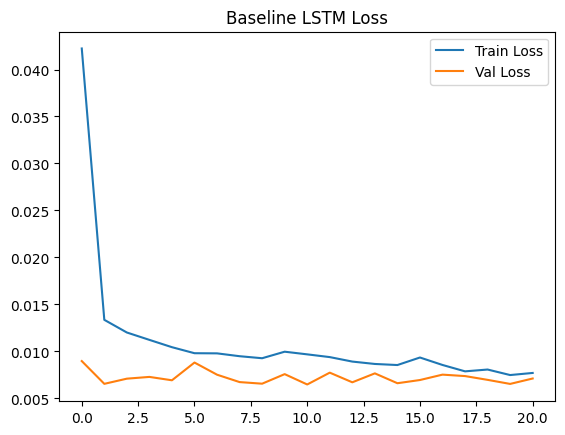

In [48]:
# 6. Build Baseline LSTM Model
model_baseline = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train Model with Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 8. Plot Training History
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Baseline LSTM Loss')
plt.legend()
plt.show()

Training Advanced Bidirectional LSTM...
Epoch 1/100


/home/arshiaask/projects/venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0788 - mae: 0.1959 - val_loss: 0.0088 - val_mae: 0.0704
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161 - mae: 0.1004 - val_loss: 0.0066 - val_mae: 0.0589
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - mae: 0.0780 - val_loss: 0.0072 - val_mae: 0.0619
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - mae: 0.0778 - val_loss: 0.0066 - val_mae: 0.0587
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0086 - mae: 0.0705 - val_loss: 0.0067 - val_mae: 0.0589
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0076 - mae: 0.0672 - val_loss: 0.0066 - val_mae: 0.0589
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0075 - mae: 0.0662 - val_loss: 0.0066 - val_mae: 0.0589
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - mae: 0.0646 - val_loss: 0.0068 - val_mae: 0.0599
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0073 - mae: 0

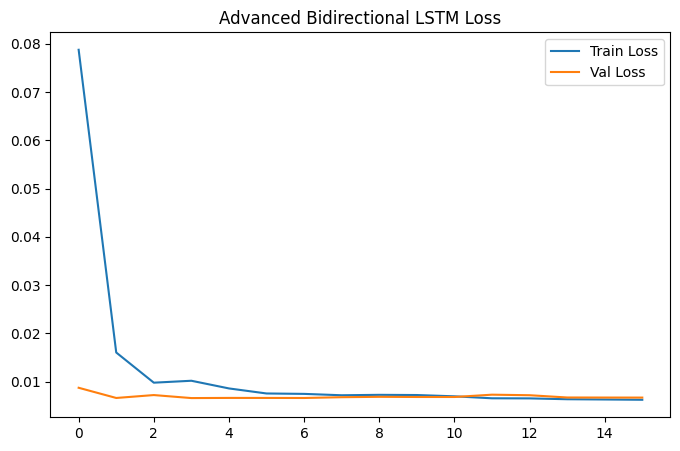

In [49]:
from keras.layers import Bidirectional

# Build Advanced Bidirectional LSTM Model
model_bidi = Sequential([
    # Layer 1: Bidirectional LSTM with return_sequences=True to feed into the next LSTM
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True), 
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    
    # Layer 2: Second Bidirectional LSTM
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.3),
    
    # Dense layers for final output
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile
model_bidi.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train Model with Early Stopping
early_stop_bidi = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("Training Advanced Bidirectional LSTM...")
history_bidi = model_bidi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_bidi],
    verbose=1
)

# Plot Training History
plt.figure(figsize=(8, 5))
plt.plot(history_bidi.history['loss'], label='Train Loss')
plt.plot(history_bidi.history['val_loss'], label='Val Loss')
plt.title('Advanced Bidirectional LSTM Loss')
plt.legend()
plt.show()

Training GRU Model...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0485 - mae: 0.1590 - val_loss: 0.0077 - val_mae: 0.0635
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - mae: 0.0842 - val_loss: 0.0092 - val_mae: 0.0730
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - mae: 0.0746 - val_loss: 0.0086 - val_mae: 0.0698
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - mae: 0.0731 - val_loss: 0.0078 - val_mae: 0.0652
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - mae: 0.0678 - val_loss: 0.0070 - val_mae: 0.0599
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0077 - mae: 0.0678 - val_loss: 0.0071 - val_mae: 0.0605
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - mae: 0.0674 - val_loss: 0.0078 - val_mae: 0.0649
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - mae: 0.0643 - val_loss: 0.0074 - val_mae: 0.0624
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s

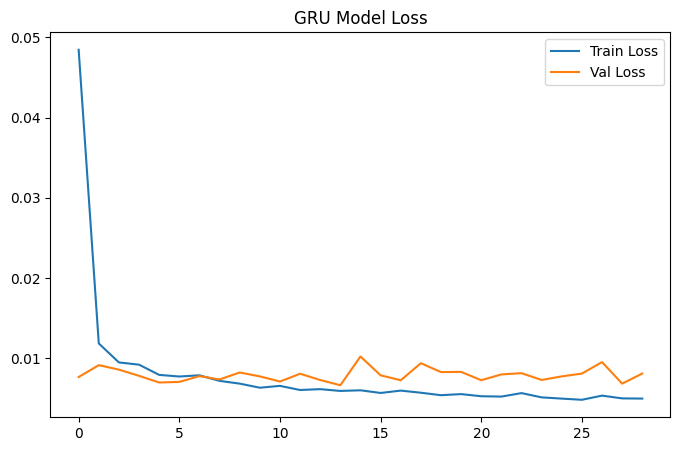

In [50]:
import tensorflow as tf
import numpy as np
import random as python_random
from keras.layers import GRU

np.random.seed(42)
python_random.seed(42)
tf.random.set_seed(42)

model_gru = Sequential([
    GRU(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    GRU(50),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop_gru = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training GRU Model...")
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_gru],
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Model Loss')
plt.legend()
plt.show()


Training XGBoost Model...
[0]	validation_0-rmse:0.05954	validation_1-rmse:0.08152
[50]	validation_0-rmse:0.04196	validation_1-rmse:0.08384
[52]	validation_0-rmse:0.04163	validation_1-rmse:0.08389

--- XGBoost Results ---
Validation MAE:  0.05884
Validation RMSE: 0.08140


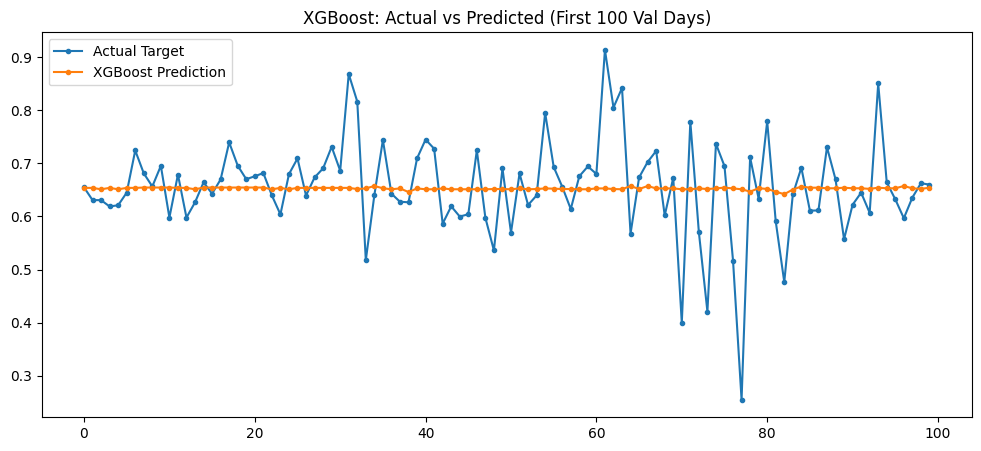

In [51]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

X_train_2d = X_train[:, -1, :] 
X_val_2d = X_val[:, -1, :]

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

xgb_model = xgb.XGBRegressor(
    n_estimators=500,        
    learning_rate=0.05,      
    max_depth=5,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    early_stopping_rounds=50  
)

print("Training XGBoost Model...")

xgb_model.fit(
    X_train_2d, y_train,
    eval_set=[(X_train_2d, y_train), (X_val_2d, y_val)],
    verbose=50                
)

y_pred_xgb = xgb_model.predict(X_val_2d)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"\n--- XGBoost Results ---")
print(f"Validation MAE:  {mae_xgb:.5f}")
print(f"Validation RMSE: {rmse_xgb:.5f}")

plt.figure(figsize=(12, 5))
plt.plot(y_val[:100], label='Actual Target', marker='.')
plt.plot(y_pred_xgb[:100], label='XGBoost Prediction', marker='.')
plt.title('XGBoost: Actual vs Predicted (First 100 Val Days)')
plt.legend()
plt.show()



In [52]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("--- Training LightGBM ---")

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,           
    num_leaves=7,          
    subsample=0.8,         
    colsample_bytree=0.8,  
    reg_alpha=0.1,         
    reg_lambda=0.5,        
    random_state=42
)

lgb_model.fit(
    X_train_2d, y_train,
    eval_set=[(X_train_2d, y_train), (X_val_2d, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

X_test_2d = X_test[:, -1, :]

lgb_preds = lgb_model.predict(X_test_2d)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
print(f"LightGBM Test RMSE: {lgb_rmse:.5f}")


--- Training LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6879
[LightGBM] [Info] Number of data points in the train set: 965, number of used features: 27
[LightGBM] [Info] Start training from score 0.653088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

/home/arshiaask/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshiaask/projects/venv/lib/python3.12/site-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
/home/arshiaask/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from catboost import CatBoostRegressor

print("\n--- Training CatBoost ---")

cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=3,               
    l2_leaf_reg=5,         
    random_seed=42,
    early_stopping_rounds=50,
    eval_metric='RMSE',
    verbose=100
)


cb_model.fit(
    X_train_2d, y_train,
    eval_set=(X_val_2d, y_val),
    use_best_model=True
)

cb_preds = cb_model.predict(X_test_2d)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_preds))
print(f"CatBoost Test RMSE: {cb_rmse:.5f}")

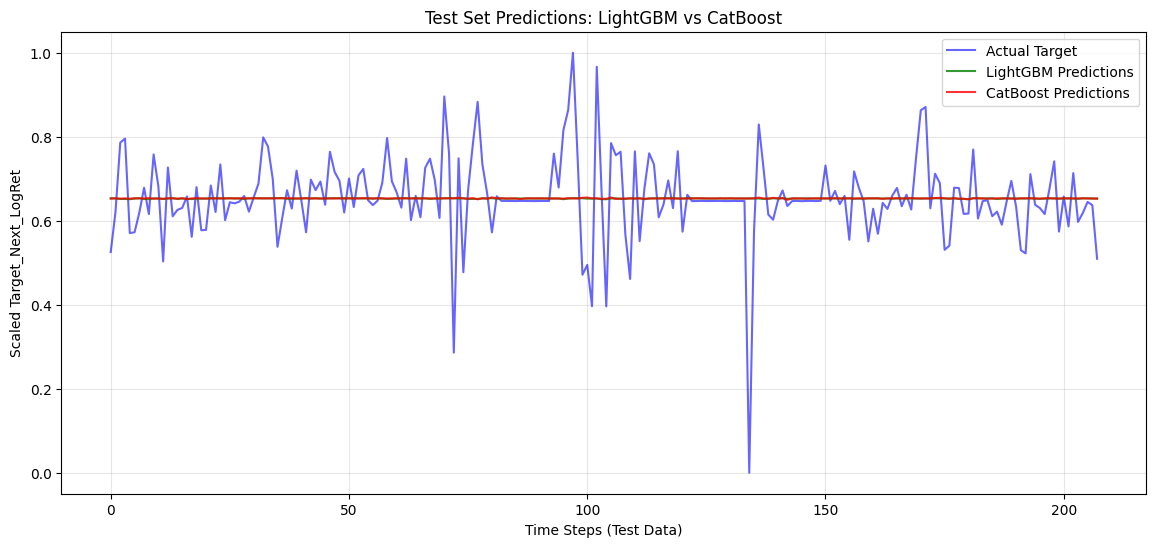

In [54]:
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual Target', color='blue', alpha=0.6)
plt.plot(lgb_preds, label='LightGBM Predictions', color='green', alpha=0.8)
plt.plot(cb_preds, label='CatBoost Predictions', color='red', alpha=0.8)

plt.title('Test Set Predictions: LightGBM vs CatBoost')
plt.xlabel('Time Steps (Test Data)')
plt.ylabel('Scaled Target_Next_LogRet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np

print("--- Flattening 3D Data for Tree Models ---")

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Old shape: {X_train.shape} -> New flattened shape: {X_train_flat.shape}")

y_train_1d = y_train.ravel()
y_val_1d = y_val.ravel()
y_test_1d = y_test.ravel()

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,           
    num_leaves=15,         
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,        
    reg_lambda=0.1,        
    random_state=42
)

lgb_model.fit(
    X_train_flat, y_train_1d,
    eval_set=[(X_train_flat, y_train_1d), (X_val_flat, y_val_1d)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

lgb_preds = lgb_model.predict(X_test_flat)
lgb_rmse = np.sqrt(mean_squared_error(y_test_1d, lgb_preds))
print(f"\nLightGBM Test RMSE (Flattened Data): {lgb_rmse:.5f}")

--- Flattening 3D Data for Tree Models ---
Old shape: (965, 14, 27) -> New flattened shape: (965, 378)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 96306
[LightGBM] [Info] Number of data points in the train set: 965, number of used features: 378
[LightGBM] [Info] Start training from score 0.653088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/home/arshiaask/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


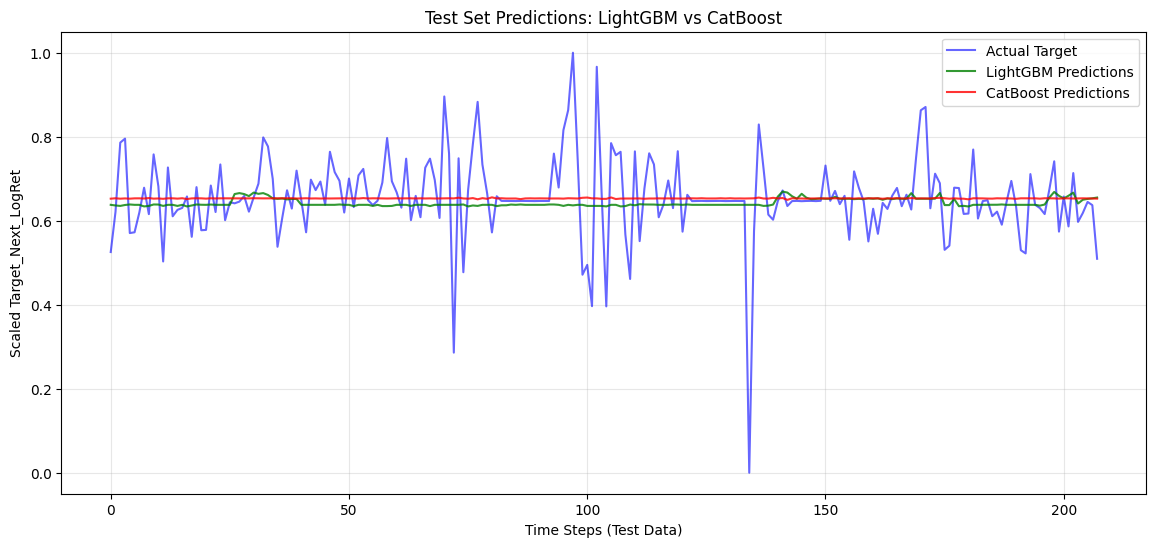

In [56]:
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual Target', color='blue', alpha=0.6)
plt.plot(lgb_preds, label='LightGBM Predictions', color='green', alpha=0.8)
plt.plot(cb_preds, label='CatBoost Predictions', color='red', alpha=0.8)

plt.title('Test Set Predictions: LightGBM vs CatBoost')
plt.xlabel('Time Steps (Test Data)')
plt.ylabel('Scaled Target_Next_LogRet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training Unrestricted LightGBM Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 96306
[LightGBM] [Info] Number of data points in the train set: 965, number of used features: 378
[LightGBM] [Info] Start training from score 0.653088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

/home/arshiaask/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/arshiaask/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


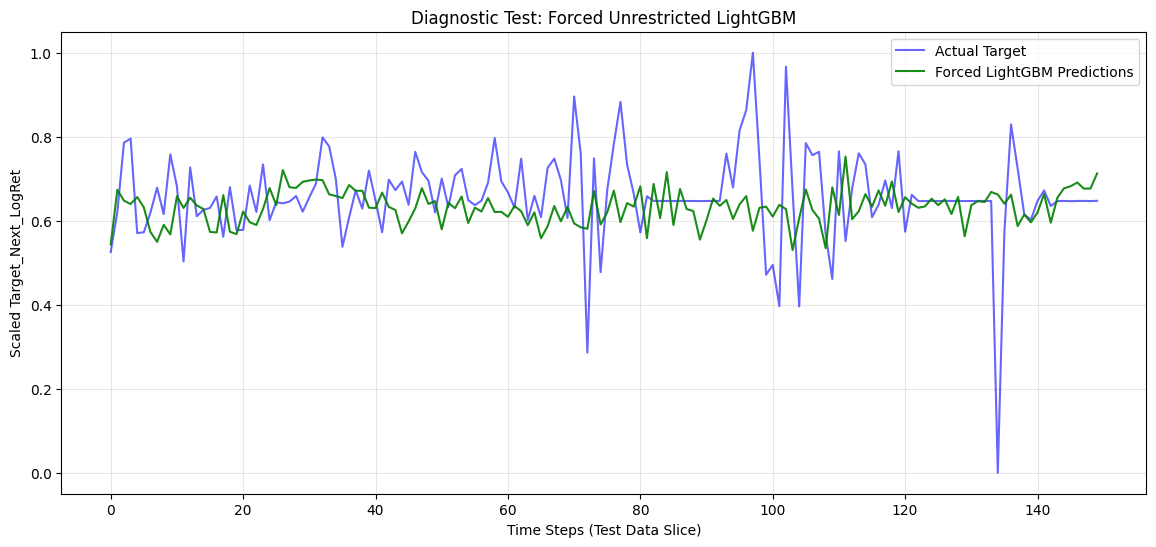

In [57]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# ---------------------------------------------------------
# DIAGNOSTIC TEST: Forcing LightGBM to Overfit
# We are removing all regularizations to see if the model 
# is capable of finding any patterns in the flattened data.
# ---------------------------------------------------------

lgb_force_model = lgb.LGBMRegressor(
    n_estimators=500,        # Number of trees
    learning_rate=0.05,      # Higher learning rate for faster adaptation
    max_depth=8,             # Deeper trees to capture complex patterns
    num_leaves=127,          # Allow more leaf nodes (2^max_depth - 1 is max)
    min_child_samples=5,     # Allow splits even if a node has very few samples
    subsample=1.0,           # Use 100% of samples per tree
    colsample_bytree=1.0,    # Use 100% of features per tree
    reg_alpha=0.0,           # No L1 regularization
    reg_lambda=0.0,          # No L2 regularization
    random_state=42
)

# Train WITHOUT early stopping to force the model to build all 500 trees
print("Training Unrestricted LightGBM Model...")
lgb_force_model.fit(
    X_train_flat, y_train_1d,
    eval_set=[(X_train_flat, y_train_1d), (X_val_flat, y_val_1d)],
    eval_metric='rmse',
    callbacks=[lgb.log_evaluation(period=50)] # No early stopping callback
)

# Predict on Train and Test sets
train_preds = lgb_force_model.predict(X_train_flat)
test_preds = lgb_force_model.predict(X_test_flat)

# Print RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_1d, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test_1d, test_preds))
print(f"\nTrain RMSE (Forced): {train_rmse:.5f}")
print(f"Test RMSE (Forced): {test_rmse:.5f}")

# ---------------------------------------------------------
# Plotting the results to visually inspect the predictions
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Plot only a slice of test data for better visibility (e.g., first 150 steps)
slice_len = min(150, len(y_test_1d))

plt.plot(y_test_1d[:slice_len], label='Actual Target', color='blue', alpha=0.6)
plt.plot(test_preds[:slice_len], label='Forced LightGBM Predictions', color='green', alpha=0.9)

plt.title('Diagnostic Test: Forced Unrestricted LightGBM')
plt.xlabel('Time Steps (Test Data Slice)')
plt.ylabel('Scaled Target_Next_LogRet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
